# 01 · Distillation reference audit and 120×120 student control

**Single responsibility:** establish a scientifically controlled, deployable student baseline before any teacher loss is introduced.

This notebook audits the accepted 160×160 teacher and its cached logits, creates independent teacher/student views from each native JPEG, trains a canonical MobileNetV1 α=0.25 student using **hard labels only**, evaluates it with a validation-selected threshold, exports full INT8, and profiles the graph. Notebook 02 must reuse this contract so the only new independent variable is the distillation loss.

## Experimental isolation

```mermaid
flowchart LR
    J[Native JPEG + hard label] --> I[Immutable image identity]
    I --> T[Teacher view: 160×160 RGB]
    I --> S[Student view: 120×120 RGB]
    T --> A[Frozen teacher audit only]
    S --> M[MobileNetV1 α=0.25]
    Y[Hard label y] --> L[Control BCE loss]
    M --> L
    L --> F[Selected float student]
    F --> Q[Full INT8 export]
    Q --> D[Desktop parity; device profile later]
```

The teacher branch cannot influence student gradients. It is inspected only to prove that the accepted knowledge source and per-image cache are ready for Notebook 02. This control answers the counterfactual: **what does the same student learn without teacher knowledge?**

## Mathematical control

For image $x_i$, hard label $y_i\in\{0,1\}$, and student logit $z_i$, the person probability is

$$p_i=\sigma(z_i)=\frac{1}{1+e^{-z_i}}.$$

With label smoothing $\varepsilon$, $\tilde y_i=(1-\varepsilon)y_i+\varepsilon/2$. The control objective is

$$\mathcal L_{control}=-\frac{1}{N}\sum_i[\tilde y_i\log p_i+(1-\tilde y_i)\log(1-p_i)]+\mathcal L_{L2}.$$

Notebook 02 adds $\lambda T^2\mathcal L_{soft}$ while keeping every control term fixed. Thus $\Delta Q=Q_{KD}-Q_{control}$ is attributable to distillation only when architecture, input transform, initialization, data, optimizer, and training budget are unchanged. The operating threshold is selected on validation—not assumed to be 0.5—and then frozen for test.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/vww-matplotlib')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '1')
current = Path.cwd().resolve()
ROOT = next(candidate for candidate in (current, *current.parents) if (candidate / 'pyproject.toml').exists())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
print(f'Repository: {ROOT}')

Repository: /Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32


In [2]:
import hashlib
import json
import platform
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import yaml
from IPython.display import Markdown, display
from sklearn.metrics import precision_recall_curve, roc_curve

from vww_esp32.config import seed_everything
from vww_esp32.evaluation import classification_metrics, expected_calibration_error, select_threshold
from vww_esp32.exporting import convert_full_integer, inspect_tflite
from vww_esp32.profiling import human_bytes, profile_model

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 100)
print({'tensorflow': tf.__version__, 'python': platform.python_version()})

{'tensorflow': '2.20.0', 'python': '3.10.13'}


## 1 · Load the registered experiment contract

Training and export are explicit switches. Checkpoints may be reused only after the configuration, manifest, teacher model, and cached-target hashes are recorded. Generated state is written under `artifacts/distillation/reference_student_120/`; the notebook and YAML remain the reproducible source.

In [3]:
CONFIG_PATH = ROOT / 'configs/distillation_student_120.yaml'

In [4]:
with CONFIG_PATH.open(encoding='utf-8') as handle:
    config = yaml.safe_load(handle)

In [5]:
SEED = int(config['project']['seed'])
TEACHER_SIZE = tuple(config['teacher']['image_size'])
STUDENT_SIZE = tuple(config['student']['image_size'])
BATCH_SIZE = int(config['preprocessing']['batch_size'])
ARTIFACT_DIR = ROOT / config['paths']['artifacts']
CHECKPOINT_DIR = ARTIFACT_DIR / 'checkpoints'
FIGURE_DIR = ARTIFACT_DIR / 'figures'
MODEL_DIR = ARTIFACT_DIR / 'models'
REPORT_DIR = ARTIFACT_DIR / 'reports'
LOG_DIR = ARTIFACT_DIR / 'logs'

In [6]:
for directory in (CHECKPOINT_DIR, FIGURE_DIR, MODEL_DIR, REPORT_DIR, LOG_DIR):
    directory.mkdir(parents=True, exist_ok=True)

In [7]:
RUN_TRAINING = True
REUSE_BEST_CHECKPOINT = True
RUN_EXPORT = True
seed_everything(SEED)
print({'teacher_size': TEACHER_SIZE, 'student_size': STUDENT_SIZE, 'batch_size': BATCH_SIZE})

{'teacher_size': (160, 160), 'student_size': (120, 120), 'batch_size': 32}


In [8]:
def sha256_file(path, chunk_bytes=1 << 20):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(chunk_bytes), b''):
            digest.update(chunk)
    return digest.hexdigest()

In [9]:
MANIFEST_PATH = ROOT / config['paths']['manifest']
TEACHER_MODEL_PATH = ROOT / config['paths']['teacher_model']
TEACHER_TARGETS_PATH = ROOT / config['paths']['teacher_targets']
TEACHER_SUMMARY_PATH = ROOT / config['paths']['teacher_summary']
required_paths = [MANIFEST_PATH, TEACHER_MODEL_PATH, TEACHER_TARGETS_PATH, TEACHER_SUMMARY_PATH]
missing = [str(path) for path in required_paths if not path.exists()]
assert not missing, f'Missing prerequisite artifacts: {missing}'
runtime_contract = {
    'config_sha256': sha256_file(CONFIG_PATH),
    'manifest_sha256': sha256_file(MANIFEST_PATH),
    'teacher_model_sha256': sha256_file(TEACHER_MODEL_PATH),
    'teacher_targets_sha256': sha256_file(TEACHER_TARGETS_PATH),
    'python': platform.python_version(), 'tensorflow': tf.__version__, 'seed': SEED,
    'teacher_input': [*TEACHER_SIZE, 3], 'student_input': [*STUDENT_SIZE, 3],
    'geometry': config['preprocessing']['geometry'],
    'teacher_antialias': bool(config['preprocessing']['teacher_antialias']),
    'student_antialias': bool(config['preprocessing']['student_antialias']),
    'control_uses_teacher_loss': False,
}
(REPORT_DIR / 'runtime_contract.json').write_text(json.dumps(runtime_contract, indent=2) + '\n')

656

In [10]:
runtime_contract

{'config_sha256': '49b8968e1c997a2754df41d46c2fd3c43e2c1a40108f72f9a71694a044c27c1a',
 'manifest_sha256': '6e25ac1d8c6b98ccc54f188e7d38ce34c9c711d1bc2242f15517680652e38704',
 'teacher_model_sha256': '8f8e0d7035e58abb710f8472ca5869bc14ebbd6dfea03ca965f86f22353ad126',
 'teacher_targets_sha256': '1bdf01ac3479958836875171895ef61c48edb05b360dd9902b6a939f001fcfc3',
 'python': '3.10.13',
 'tensorflow': '2.20.0',
 'seed': 42,
 'teacher_input': [160, 160, 3],
 'student_input': [120, 120, 3],
 'geometry': 'letterbox',
 'teacher_antialias': True,
 'student_antialias': False,
 'control_uses_teacher_loss': False}

## 2 · Audit teacher approval and cached knowledge

The cache is joined by immutable `image_id`, never by row position. We require one target for every manifest row, exact label and split agreement, finite logits, valid probabilities, and a teacher that passed its earlier acceptance gate. A silent row shift would make later KD train on the wrong images.

In [11]:
manifest = pd.read_csv(MANIFEST_PATH)

In [12]:
targets = pd.read_csv(TEACHER_TARGETS_PATH)

In [13]:
teacher_summary = json.loads(TEACHER_SUMMARY_PATH.read_text())

In [14]:
required_manifest = {'image_id', 'image_path', 'split', 'label', 'width', 'height', 'aspect_ratio', 'max_person_area_fraction'}
required_targets = {'image_id', 'split', 'label', 'teacher_probability', 'teacher_logit'}
assert required_manifest <= set(manifest) and required_targets <= set(targets)
assert manifest.image_id.is_unique and targets.image_id.is_unique
assert set(manifest.image_id) == set(targets.image_id)

In [15]:
audit = manifest[['image_id', 'split', 'label']].merge(
    targets[['image_id', 'split', 'label', 'teacher_probability', 'teacher_logit']],
    on='image_id', 
    suffixes=('_manifest', '_teacher'), 
    validate='one_to_one'
)

In [16]:
assert (audit.split_manifest == audit.split_teacher).all()
assert (audit.label_manifest == audit.label_teacher).all()
assert np.isfinite(audit[['teacher_probability', 'teacher_logit']]).all().all()
assert audit.teacher_probability.between(0, 1).all()
assert bool(teacher_summary['approved_for_distillation'])
assert manifest.image_path.map(lambda value: Path(value).exists()).all()

In [17]:
splits = {name: manifest[manifest.split == name].sort_values('image_id').reset_index(drop=True) for name in ('train', 'val', 'test')}
split_summary = manifest.groupby('split').agg(samples=('image_id', 'size'), positives=('label', 'sum'))
split_summary['positive_fraction'] = split_summary.positives / split_summary.samples
split_summary.to_csv(REPORT_DIR / 'dataset_split_summary.csv')

In [18]:
teacher_audit = {
    'approved': True, 'rows': len(audit),
    'test_f1': teacher_summary['test_metrics']['f1'],
    'test_pr_auc': teacher_summary['test_metrics']['pr_auc'],
    'validation_threshold': teacher_summary['validation_threshold'],
}
display(split_summary)
display(pd.Series(teacher_audit))

,samples,positives,positive_fraction
split,,,
test,2000,981,0.4905
train,12000,6000,0.5000
val,2000,989,0.4945


approved                    True
rows                       16000
test_f1                 0.846353
test_pr_auc             0.930476
validation_threshold       0.365
dtype: object

## 3 · Paired preprocessing

For native width $W$, height $H$, and target side $R$, letterboxing uses $s_R=\min(R/W,R/H)$. The accepted teacher keeps its registered antialiasing; the MCU student disables it so firmware can reproduce the resize. Each branch starts from the native JPEG—never from another resized tensor.

In [19]:
AUTOTUNE = tf.data.AUTOTUNE

In [20]:
def decode_letterbox(path, label, size, antialias):
    image = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    image = tf.image.resize_with_pad(image, size[0], size[1], method=config['preprocessing']['resize_method'], antialias=bool(antialias))
    image = tf.cast(tf.clip_by_value(image, 0, 255), tf.float32)
    image.set_shape((*size, 3))
    return image, tf.cast(label, tf.float32)

In [21]:
def make_dataset(frame, size, training=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((frame.image_path.astype(str).to_numpy(), frame.label.astype('float32').to_numpy()))
    options = tf.data.Options(); options.experimental_deterministic = not training; ds = ds.with_options(options)
    if training: ds = ds.shuffle(min(len(frame), 4096), seed=SEED, reshuffle_each_iteration=True)
    antialias = config['preprocessing']['teacher_antialias'] if tuple(size) == TEACHER_SIZE else config['preprocessing']['student_antialias']
    ds = ds.map(lambda path, label: decode_letterbox(path, label, size, antialias), num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

In [22]:
train_ds = make_dataset(splits['train'], STUDENT_SIZE, training=True)
train_eval_ds = make_dataset(splits['train'], STUDENT_SIZE)
val_ds = make_dataset(splits['val'], STUDENT_SIZE)
test_ds = make_dataset(splits['test'], STUDENT_SIZE)

In [23]:
images, labels = next(iter(train_eval_ds))
assert images.shape[1:] == (*STUDENT_SIZE, 3) and images.dtype == tf.float32
print(images.shape, float(tf.reduce_min(images)), float(tf.reduce_max(images)))

(32, 120, 120, 3) 0.0 255.0


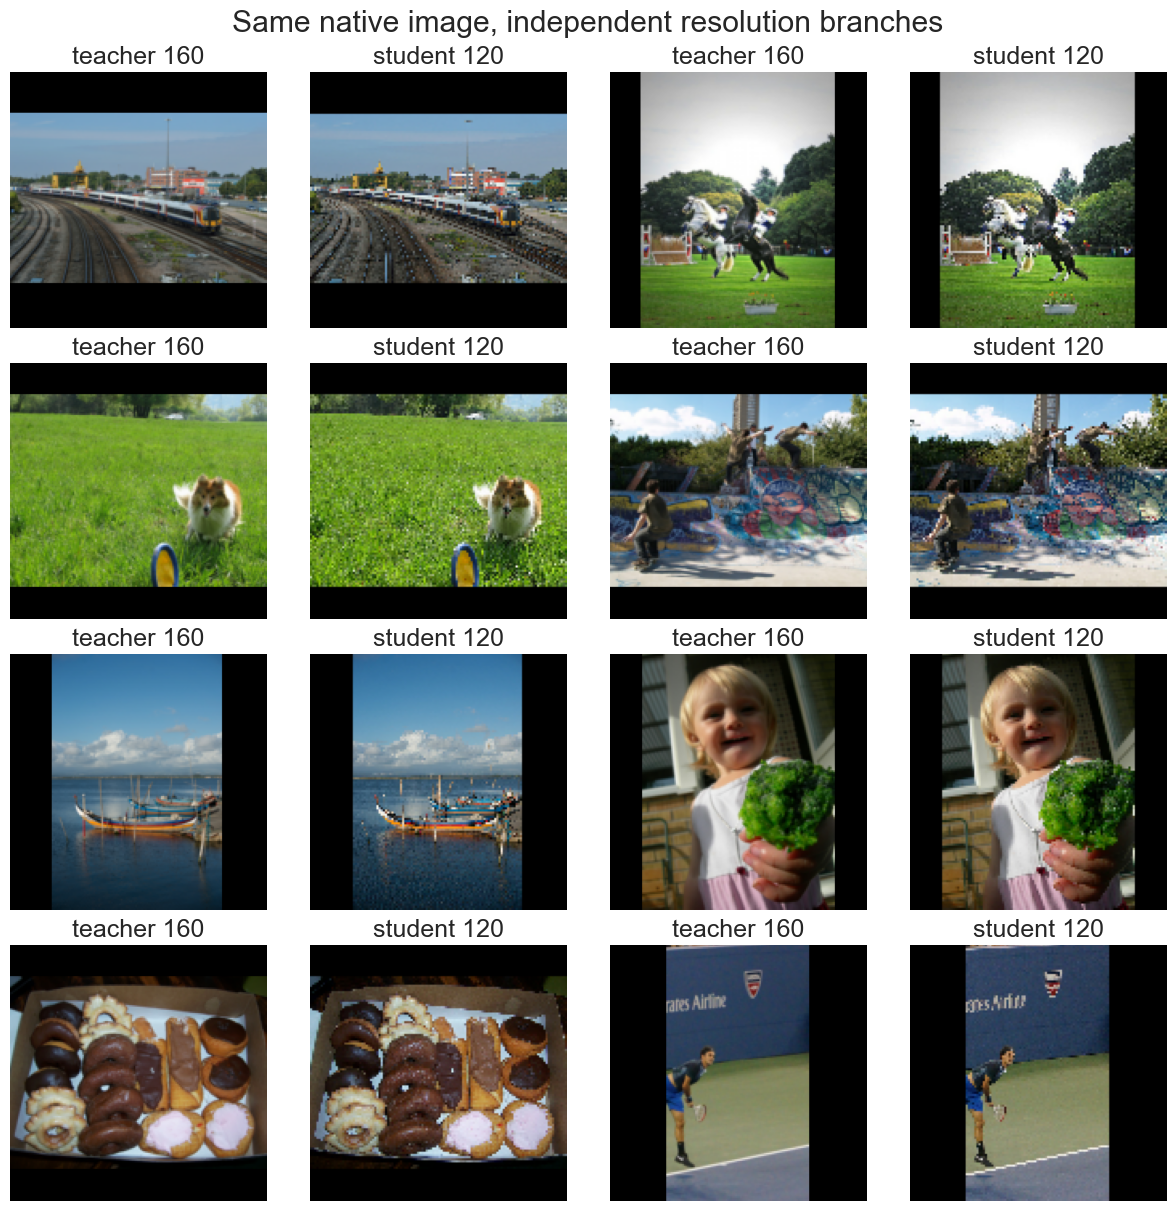

In [24]:
preview = pd.concat([splits['train'][splits['train'].label == 0].head(4), splits['train'][splits['train'].label == 1].head(4)]).sort_values(['label', 'image_id'])
teacher_images = next(iter(make_dataset(preview, TEACHER_SIZE, batch_size=8)))[0].numpy().astype(np.uint8)
student_images = next(iter(make_dataset(preview, STUDENT_SIZE, batch_size=8)))[0].numpy().astype(np.uint8)
fig, axes = plt.subplots(4, 4, figsize=(12, 12), constrained_layout=True)
for row in range(4):
    for offset, index in enumerate((row, row + 4)):
        axes[row, offset * 2].imshow(teacher_images[index]); axes[row, offset * 2 + 1].imshow(student_images[index])
        axes[row, offset * 2].set_title('teacher 160'); axes[row, offset * 2 + 1].set_title('student 120')
        axes[row, offset * 2].axis('off'); axes[row, offset * 2 + 1].axis('off')
fig.suptitle('Same native image, independent resolution branches')
fig.savefig(FIGURE_DIR / 'paired_input_contract.png', dpi=180)
plt.show()

## 4 · Canonical MobileNetV1 student

A standard convolution costs $H_oW_oK^2C_{in}C_{out}$ MACs. MobileNet factorizes this into $H_oW_oK^2C_{in}+H_oW_oC_{in}C_{out}$. Width multiplier $\alpha$ mainly scales pointwise compute as $\alpha^2$; changing 160 to 120 scales spatial work by $(120/160)^2=0.5625$. Raw `person_logit` is exposed for Notebook 02; `person_probability` remains the deployable sigmoid output.

In [25]:
aug = config['augmentation']

In [26]:
augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            'horizontal', 
            seed=SEED
        ), 
        tf.keras.layers.RandomTranslation(
            aug['translation_fraction'], 
            aug['translation_fraction'], 
            fill_mode='reflect', 
            seed=SEED + 1
        ), 
        tf.keras.layers.RandomBrightness(
            aug['brightness_delta'], 
            value_range=(-1, 1), 
            seed=SEED + 2
        ), 
        tf.keras.layers.RandomContrast(
            aug['contrast_factor'], 
            seed=SEED + 3
        ), 
        tf.keras.layers.RandomSaturation(
            aug['saturation_factor'], 
            value_range=(-1, 1), 
            seed=SEED + 4
        ), 
        tf.keras.layers.GaussianNoise(
            aug['sensor_noise_stddev'], 
            seed=SEED + 5
        )
    ], 
    name='camera_augmentation'
)

Student Archiecture

In [27]:
def build_student(weights='imagenet'):
    inputs = tf.keras.Input(
        (*STUDENT_SIZE, 3), 
        name='image'
    )
    x = tf.keras.layers.Rescaling(
        1 / 127.5, 
        offset=-1, 
        name='normalize'
    )(inputs)
    
    x = augmentation(x)
    
    backbone = tf.keras.applications.MobileNet(
        input_tensor=x, 
        input_shape=(*STUDENT_SIZE, 3), 
        alpha=float(
            config['student']['width_multiplier']
        ), 
        include_top=False, 
        weights=weights
    )
    
    x = tf.keras.layers.GlobalAveragePooling2D(name='global_average')(backbone.output)
    x = tf.keras.layers.Dropout(
        float(config['student']['dropout']), 
        name='student_dropout'
    )(x)

    # output
    logits = tf.keras.layers.Dense(
        1, 
        kernel_regularizer=tf.keras.regularizers.l2(
            float(config['student']['l2'])
        ), 
        name='person_logit'
    )(x)
    outputs = tf.keras.layers.Activation(
        'sigmoid', 
        name='person_probability'
    )(logits)
    
    return tf.keras.Model(
        inputs, 
        outputs, 
        name='vww_student_120_a025_control'
    ), backbone

In [28]:
student, backbone = build_student('imagenet' if config['student']['imagenet_initialization'] else None)

/var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/ipykernel_23990/2864082062.py:14: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = tf.keras.applications.MobileNet(


In [29]:
backbone_names = {layer.name for layer in backbone.layers}

In [30]:
layers, liveness, static_profile = profile_model(
    student, 
    batch_size=1, 
    training_batch_size=BATCH_SIZE
)

In [31]:
assert student.count_params() == 218801 and static_profile['estimated_macs_batch1'] == 10487648

In [32]:
layers.to_csv(REPORT_DIR / 'student_layer_profile_untrained.csv', index=False)
liveness.to_csv(REPORT_DIR / 'student_activation_liveness_untrained.csv', index=False)
(REPORT_DIR / 'student_static_profile_untrained.json').write_text(json.dumps(static_profile, indent=2) + '\n')
display(pd.Series(static_profile)[['parameters', 'estimated_macs_batch1', 'peak_live_activation_int8_bytes_batch1_hypothetical', 'peak_live_activation_layer']])

parameters                                                 218801
estimated_macs_batch1                                    10487648
peak_live_activation_int8_bytes_batch1_hypothetical        117136
peak_live_activation_layer                             conv_pad_2
dtype: object

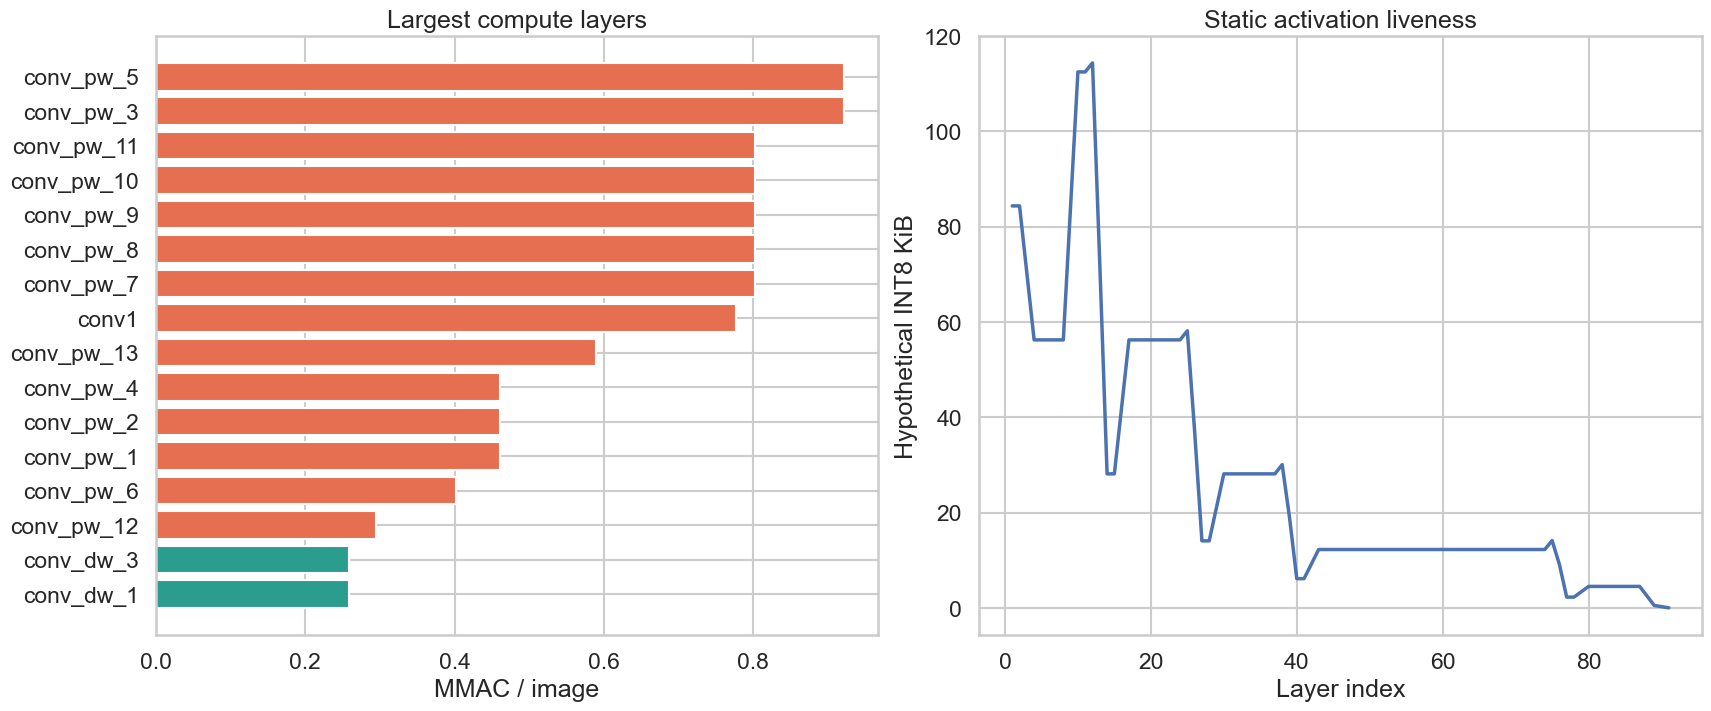

In [33]:
top = layers[layers.estimated_macs_batch1 > 0].nlargest(16, 'estimated_macs_batch1').sort_values('estimated_macs_batch1')
fig, axes = plt.subplots(1, 2, figsize=(17, 7), constrained_layout=True)
axes[0].barh(top.layer_name, top.estimated_macs_batch1 / 1e6, color=np.where(top.layer_type == 'DepthwiseConv2D', '#2a9d8f', '#e76f51'))
axes[0].set(title='Largest compute layers', xlabel='MMAC / image')
axes[1].plot(liveness.layer_index, liveness.live_int8_bytes_hypothetical / 1024, linewidth=2.5)
axes[1].set(title='Static activation liveness', xlabel='Layer index', ylabel='Hypothetical INT8 KiB')
fig.savefig(FIGURE_DIR / 'student_architecture_profile.png', dpi=180)
plt.show()

## 5 · Hard-label control training

Stage A learns the binary head with a frozen ImageNet backbone. Stage B fine-tunes only the final configured layers while BatchNorm remains frozen. Validation PR-AUC selects checkpoints; the test split never controls training.

In [34]:
def compile_student(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(float(lr)), 
        loss=tf.keras.losses.BinaryCrossentropy(
            label_smoothing=float(config['training']['label_smoothing'])
        ), 
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'), 
            tf.keras.metrics.Precision(name='precision'), 
            tf.keras.metrics.Recall(name='recall'), 
            tf.keras.metrics.AUC(curve='ROC', name='roc_auc'), 
            tf.keras.metrics.AUC(curve='PR', name='pr_auc')
        ]
    )

In [35]:
def callbacks(stage):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            CHECKPOINT_DIR / f'best_{stage}.keras', 
            monitor='val_pr_auc', 
            mode='max', 
            save_best_only=True
        ), 
        tf.keras.callbacks.EarlyStopping(
            monitor='val_pr_auc', 
            mode='max', 
            patience=int(config['training']['early_stopping_patience']), 
            restore_best_weights=True
        ), 
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_pr_auc', 
            mode='max', 
            factor=.3, 
            patience=int(config['training']['reduce_lr_patience']), 
            min_lr=1e-7
        ), 
        tf.keras.callbacks.CSVLogger(LOG_DIR / f'{stage}.csv'), 
        tf.keras.callbacks.TerminateOnNaN()
    ]

In [36]:
for layer in student.layers:
    if layer.name in backbone_names: layer.trainable = False

In [37]:
compile_student(
    student, 
    config['training']['head_learning_rate']
)

In [38]:
stage_a = CHECKPOINT_DIR / 'best_stage_a.keras'

HEAD

In [39]:
if stage_a.exists() and REUSE_BEST_CHECKPOINT: student = tf.keras.models.load_model(stage_a)
elif RUN_TRAINING: 
    student.fit(
        train_ds, 
        validation_data=val_ds, 
        epochs=int(config['training']['head_epochs']), 
        callbacks=callbacks('stage_a')
    )
else: 
    print('Stage A disabled.')

In [40]:
stage_b = CHECKPOINT_DIR / 'best_stage_b.keras'

In [41]:
FINAL_MODEL = MODEL_DIR / 'student_120_hard_control.keras'

FINETUNE LAST LAYERS

In [42]:
if stage_b.exists() and REUSE_BEST_CHECKPOINT:
    student = tf.keras.models.load_model(stage_b, compile=False)
    student.save(FINAL_MODEL)
elif RUN_TRAINING and stage_a.exists():
    student = tf.keras.models.load_model(stage_a, compile=False)
    mobile = [layer for layer in student.layers if layer.name in backbone_names]
    cutoff = max(0, len(mobile) - int(config['training']['fine_tune_last_layers']))
    for index, layer in enumerate(mobile): 
        layer.trainable = index >= cutoff and not isinstance(layer, tf.keras.layers.BatchNormalization)
    compile_student(
        student, 
        config['training']['fine_tune_learning_rate']
    )
    student.fit(
        train_ds, 
        validation_data=val_ds, 
        epochs=int(config['training']['fine_tune_epochs']), 
        callbacks=callbacks('stage_b')
    )
    student = tf.keras.models.load_model(stage_b, compile=False)
    student.save(FINAL_MODEL)
else: print('Stage B disabled or waiting for Stage A.')

In [43]:
logs = []

In [44]:
for name, path in [('head', LOG_DIR / 'stage_a.csv'), ('fine-tune', LOG_DIR / 'stage_b.csv')]:
    if path.exists():
        frame = pd.read_csv(path); frame['stage'] = name; logs.append(frame)

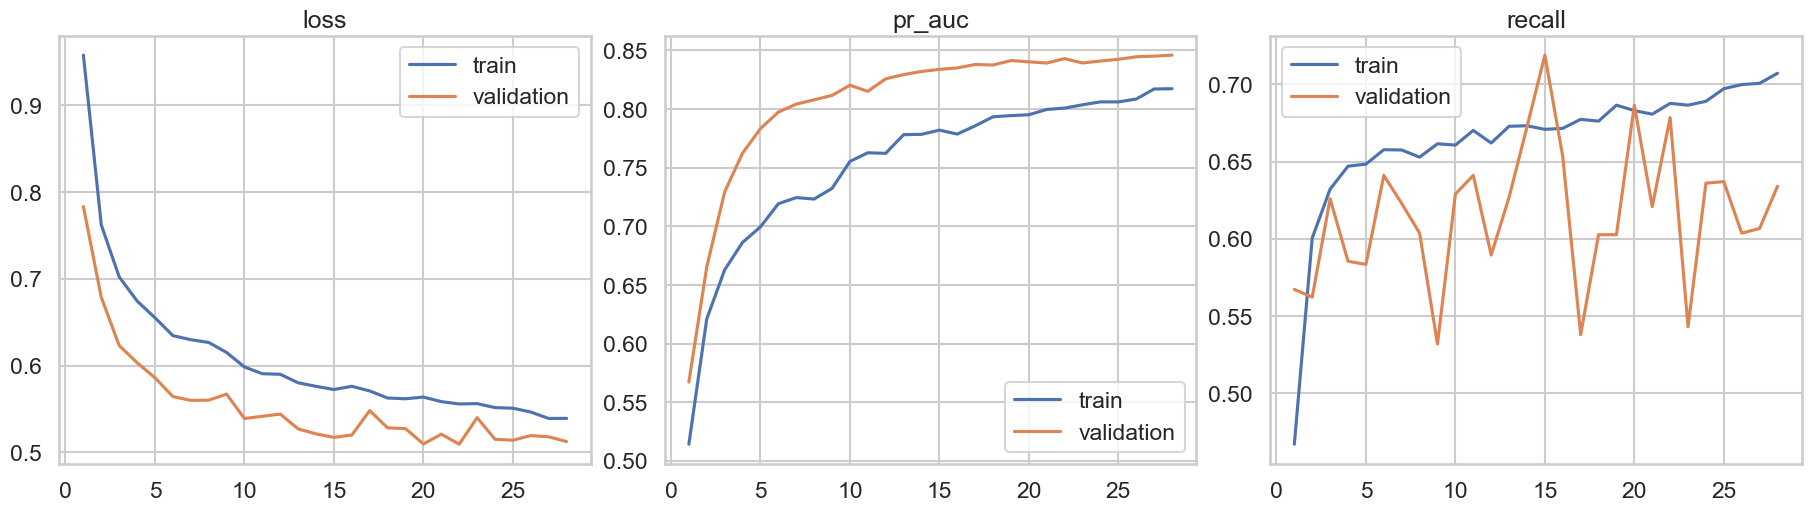

In [45]:
if logs:
    history = pd.concat(logs, ignore_index=True)
    history['epoch_all'] = np.arange(1, len(history) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    for metric, ax in zip(['loss', 'pr_auc', 'recall'], axes):
        ax.plot(history.epoch_all, history[metric], label='train')
        ax.plot(history.epoch_all, history[f'val_{metric}'], label='validation')
        ax.set_title(metric)
        ax.legend()
    fig.savefig(FIGURE_DIR / 'student_learning_curves.png', dpi=180)
    plt.show()
else: print('Learning curves await training.')

## 6 · Validation threshold, test quality, and teacher headroom

Validation chooses $\tau$ under the registered recall constraint. Test is evaluated once. Teacher-correct/student-wrong examples quantify potential KD headroom without affecting training.

In [46]:
def predict(model, dataset):
    y = np.concatenate(
        [np.asarray(labels).reshape(-1) for _, labels in dataset]
    ).astype(np.int8)
    return y, model.predict(dataset, verbose=0).reshape(-1).astype(np.float32)

In [47]:
MODEL_READY = FINAL_MODEL.exists()

In [48]:
if MODEL_READY:
    student = tf.keras.models.load_model(
        FINAL_MODEL, 
        compile=False
    )

    # VALIDATION 
    y_val, p_val = predict(
        student, 
        val_ds
    )
    
    selected = select_threshold(
        y_val, 
        p_val, 
        objective=config['evaluation']['threshold_objective'], 
        minimum_recall=float(config['evaluation']['minimum_recall']), 
        false_positive_cost=float(config['evaluation']['false_positive_cost']), 
        false_negative_cost=float(config['evaluation']['false_negative_cost'])
    )
    
    THRESHOLD = float(selected['threshold'])

    val_metrics = classification_metrics(
        y_val, 
        p_val, 
        THRESHOLD
    )

    # TEST
    y_test, p_test = predict(student, test_ds)
    test_metrics = classification_metrics(
        y_test, 
        p_test, 
        THRESHOLD
    )

    test_metrics['ece_10'] = expected_calibration_error(y_test, p_test, bins=10)
    (REPORT_DIR / 'validation_metrics_float.json').write_text(json.dumps(val_metrics, indent=2) + '\n')
    (REPORT_DIR / 'test_metrics_float.json').write_text(json.dumps(test_metrics, indent=2) + '\n')
    ordered = splits['test'][['image_id', 'label', 'max_person_area_fraction']].copy(); ordered['student_probability'] = p_test
    agreement = ordered.merge(targets[['image_id', 'teacher_probability']], on='image_id', validate='one_to_one')
    agreement['student_correct'] = ((agreement.student_probability >= THRESHOLD).astype(int) == agreement.label)
    agreement['teacher_correct'] = ((agreement.teacher_probability >= float(teacher_summary['validation_threshold'])).astype(int) == agreement.label)
    
    headroom = {
        'teacher_correct_student_wrong': int((agreement.teacher_correct & ~agreement.student_correct).sum()), 
        'student_correct_teacher_wrong': int((agreement.student_correct & ~agreement.teacher_correct).sum()), 
        'probability_mae': float(np.mean(np.abs(agreement.teacher_probability - agreement.student_probability)))
    }
    display(pd.Series(test_metrics)); display(pd.Series(headroom))
else:
    THRESHOLD = val_metrics = test_metrics = headroom = y_test = p_test = None
    print('Evaluation awaits training.')

samples                                        2000
threshold                                      0.31
accuracy                                      0.738
precision                                  0.703111
recall                                      0.80632
f1                                         0.751187
roc_auc                                    0.831842
pr_auc                                     0.840623
specificity                                0.672228
confusion_matrix           [[685, 334], [190, 791]]
positive_prevalence                          0.4905
predicted_positive_rate                      0.5625
ece_10                                     0.061097
dtype: object

teacher_correct_student_wrong    310.000000
student_correct_teacher_wrong     83.000000
probability_mae                    0.164961
dtype: float64

In [49]:
if MODEL_READY:
    precision, recall, _ = precision_recall_curve(y_test, p_test)
    fpr, tpr, _ = roc_curve(y_test, p_test)

    sns.heatmap(np.asarray(test_metrics['confusion_matrix']), annot=True, fmt='d', cbar=False, ax=axes[0])
    axes[0].set(title=f'Confusion @ {THRESHOLD:.2f}', xlabel='Predicted', ylabel='True')
    axes[1].plot(recall, precision, label=f"PR {test_metrics['pr_auc']:.3f}")
    axes[1].plot(fpr, tpr, label=f"ROC {test_metrics['roc_auc']:.3f}")
    axes[1].legend(); axes[1].set_title('Ranking curves')
    axes[2].scatter(agreement.teacher_probability, agreement.student_probability, c=agreement.label, alpha=.3, s=15)
    axes[2].plot([0,1],[0,1],'--')
    axes[2].set(title='Teacher–student agreement', xlabel='Teacher', ylabel='Student')
    fig.savefig(FIGURE_DIR / 'student_quality_and_headroom.png', dpi=180)
    plt.show()
else: 
    print('Quality figures await training.')

## 7 · Full-INT8 deployment control

Affine quantization uses $q=\operatorname{clip}(\operatorname{round}(r/s)+z,-128,127)$. This PTQ export verifies the integer graph and numerical parity; it does not measure ESP32 tensor-arena use or latency.

In [50]:
TFLITE_PATH = MODEL_DIR / config['export']['model_filename']

In [51]:
if MODEL_READY and RUN_EXPORT:
    representative = splits['train'].sample(n=min(int(config['export']['representative_samples']), len(splits['train'])), random_state=SEED)
    representative_ds = make_dataset(representative, STUDENT_SIZE, batch_size=1)
    def representative_data():
        for batch, _ in representative_ds: yield [batch.numpy().astype(np.float32)]
        
    # Rebuild an inference-only graph. Training augmentation owns RNG variables that
    # must not leak into a TensorFlow Lite Micro deployment model.
    def build_deploy_student():
        inputs = tf.keras.Input((*STUDENT_SIZE, 3), name='image')
        x = tf.keras.layers.Rescaling(1 / 127.5, offset=-1, name='normalize')(inputs)
        backbone = tf.keras.applications.MobileNet(input_tensor=x, input_shape=(*STUDENT_SIZE, 3), alpha=float(config['student']['width_multiplier']), include_top=False, weights=None)
        x = tf.keras.layers.GlobalAveragePooling2D(name='global_average')(backbone.output)
        logits = tf.keras.layers.Dense(1, name='person_logit')(x)
        outputs = tf.keras.layers.Activation('sigmoid', name='person_probability')(logits)
        model = tf.keras.Model(inputs, outputs, name='vww_student_120_a025_deploy')
        for layer in model.layers:
            if not layer.weights:
                continue
            source = student.get_layer(layer.name)
            assert [tuple(w.shape) for w in layer.weights] == [tuple(w.shape) for w in source.weights]
            layer.set_weights(source.get_weights())
        return model
    deploy_student = build_deploy_student()
    parity_batch = next(iter(val_ds))[0]
    deploy_graph_mae = float(tf.reduce_mean(tf.abs(student(parity_batch, training=False) - deploy_student(parity_batch, training=False))))
    assert deploy_graph_mae < 1e-6, deploy_graph_mae
    deploy_student.save(MODEL_DIR / 'student_120_hard_control_deploy.keras')
    convert_full_integer(deploy_student, representative_data(), TFLITE_PATH)

INFO:tensorflow:Assets written to: /var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmpjckr_2xn/assets


INFO:tensorflow:Assets written to: /var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmpjckr_2xn/assets


Saved artifact at '/var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmpjckr_2xn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 120, 120, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  4821164176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4821190608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4821197472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4821188672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4821194832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4821201872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4821238880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4821203104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4821199584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4821238176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4821245216: TensorSpec(shap

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1790325164.128967  457276 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790325164.128979  457276 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790325164.151559  457276 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
2026-09-25 15:32:48.982035: W tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3705] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [52]:
export_info = inspect_tflite(TFLITE_PATH) if TFLITE_PATH.exists() else None

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [53]:
if export_info:
    assert export_info['input']['dtype'] == 'int8' and export_info['output']['dtype'] == 'int8'
    (REPORT_DIR / 'export_info.json').write_text(json.dumps(export_info, indent=2) + '\n'); display(pd.Series(export_info))
else: print('INT8 export awaits training.')

size_bytes                                               304296
input         {'name': 'serving_default_image:0', 'shape': [...
output        {'name': 'StatefulPartitionedCall_1:0', 'shape...
operators     [ADD, CONV_2D, DEPTHWISE_CONV_2D, FULLY_CONNEC...
dtype: object

In [54]:
def predict_tflite(path, dataset):
    interpreter = tf.lite.Interpreter(model_path=str(path))
    interpreter.allocate_tensors()
    inp, out = interpreter.get_input_details()[0], interpreter.get_output_details()[0]
    si, zi = inp['quantization']; so, zo = out['quantization']
    labels, probabilities = [], []
    for batch, truth in dataset:
        for image, label in zip(batch.numpy(), truth.numpy()):
            interpreter.set_tensor(inp['index'], np.clip(np.round(image / si + zi), -128, 127).astype(np.int8)[None])
            interpreter.invoke(); raw = interpreter.get_tensor(out['index'])[0, 0]
            labels.append(int(label))
            probabilities.append((float(raw) - zo) * so)
    return np.asarray(labels), np.asarray(probabilities)

In [55]:
if MODEL_READY and export_info:
    yi_val, pi_val = predict_tflite(TFLITE_PATH, val_ds)
    choice_i = select_threshold(
        yi_val, 
        pi_val, 
        objective='f1', 
        minimum_recall=float(config['evaluation']['minimum_recall'])
    )
    INT8_THRESHOLD = float(choice_i['threshold'])
    yi_test, pi_test = predict_tflite(TFLITE_PATH, test_ds)
    int8_metrics = classification_metrics(yi_test, pi_test, INT8_THRESHOLD)
    parity = {
        'probability_mae': float(np.mean(np.abs(p_test - pi_test))), 
        'f1_delta': float(int8_metrics['f1'] - test_metrics['f1']), 
        'pr_auc_delta': float(int8_metrics['pr_auc'] - test_metrics['pr_auc'])
    }
    (REPORT_DIR / 'test_metrics_int8.json').write_text(json.dumps(int8_metrics, indent=2) + '\n')
    display(pd.Series(parity))
else: INT8_THRESHOLD = int8_metrics = parity = None

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


probability_mae    0.036313
f1_delta           0.003232
pr_auc_delta      -0.005359
dtype: float64

## 8 · Acceptance report

The control may be promoted to Notebook 02 when artifact identity, float evaluation, integer export, and parity gates pass. Physical-device readiness remains false until actual ESP32-CAM and ESP32-S3 profiling.

In [56]:
if MODEL_READY and int8_metrics:
    gates = {'teacher_cache_valid': len(audit) == len(manifest), 'integer_only': export_info['input']['dtype'] == 'int8' and export_info['output']['dtype'] == 'int8', 'parity_mae': parity['probability_mae'] <= float(config['control_gate']['maximum_float_to_int8_probability_mae']), 'int8_f1_retained': parity['f1_delta'] >= -float(config['control_gate']['maximum_int8_f1_drop']), 'device_profile_complete': False}
    ready_for_response_kd = gates['teacher_cache_valid'] and np.isfinite(test_metrics['pr_auc']) and np.isfinite(test_metrics['f1'])
    ready_for_int8_deployment = gates['integer_only'] and gates['parity_mae'] and gates['int8_f1_retained'] and gates['device_profile_complete']
    summary = {'experiment': 'student_120_hard_control', 'runtime_contract': runtime_contract, 'teacher_audit': teacher_audit, 'float_test_metrics': test_metrics, 'int8_test_metrics': int8_metrics, 'parity': parity, 'static_profile': static_profile, 'headroom': headroom, 'gates': gates, 'ready_for_response_kd': bool(ready_for_response_kd), 'ready_for_int8_deployment': bool(ready_for_int8_deployment)}
    (REPORT_DIR / 'experiment_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
    report = f"""# Student 120 hard-control report

- Parameters: {static_profile['parameters']:,}
- MACs: {static_profile['estimated_macs_batch1']:,}
- Float F1 / PR-AUC: {test_metrics['f1']:.4f} / {test_metrics['pr_auc']:.4f}
- INT8 F1 / PR-AUC: {int8_metrics['f1']:.4f} / {int8_metrics['pr_auc']:.4f}
- Ready for response KD: **{summary['ready_for_response_kd']}**
- Ready for INT8 deployment: **{summary['ready_for_int8_deployment']}**
- Device profiling complete: **{gates['device_profile_complete']}**
"""
    (REPORT_DIR / 'DISTILLATION_REFERENCE_REPORT.md').write_text(report); display(Markdown(report))
else: print('Final report awaits training and export.')

# Student 120 hard-control report

- Parameters: 218,801
- MACs: 10,487,648
- Float F1 / PR-AUC: 0.7512 / 0.8406
- INT8 F1 / PR-AUC: 0.7544 / 0.8353
- Ready for response KD: **True**
- Ready for INT8 deployment: **False**
- Device profiling complete: **False**


## 9 · Complete post-run evaluation dashboard

This block deliberately reloads the saved reference metrics and creates all confusion, quality, resource, and error-slice figures after training. It is safe to rerun without retraining.

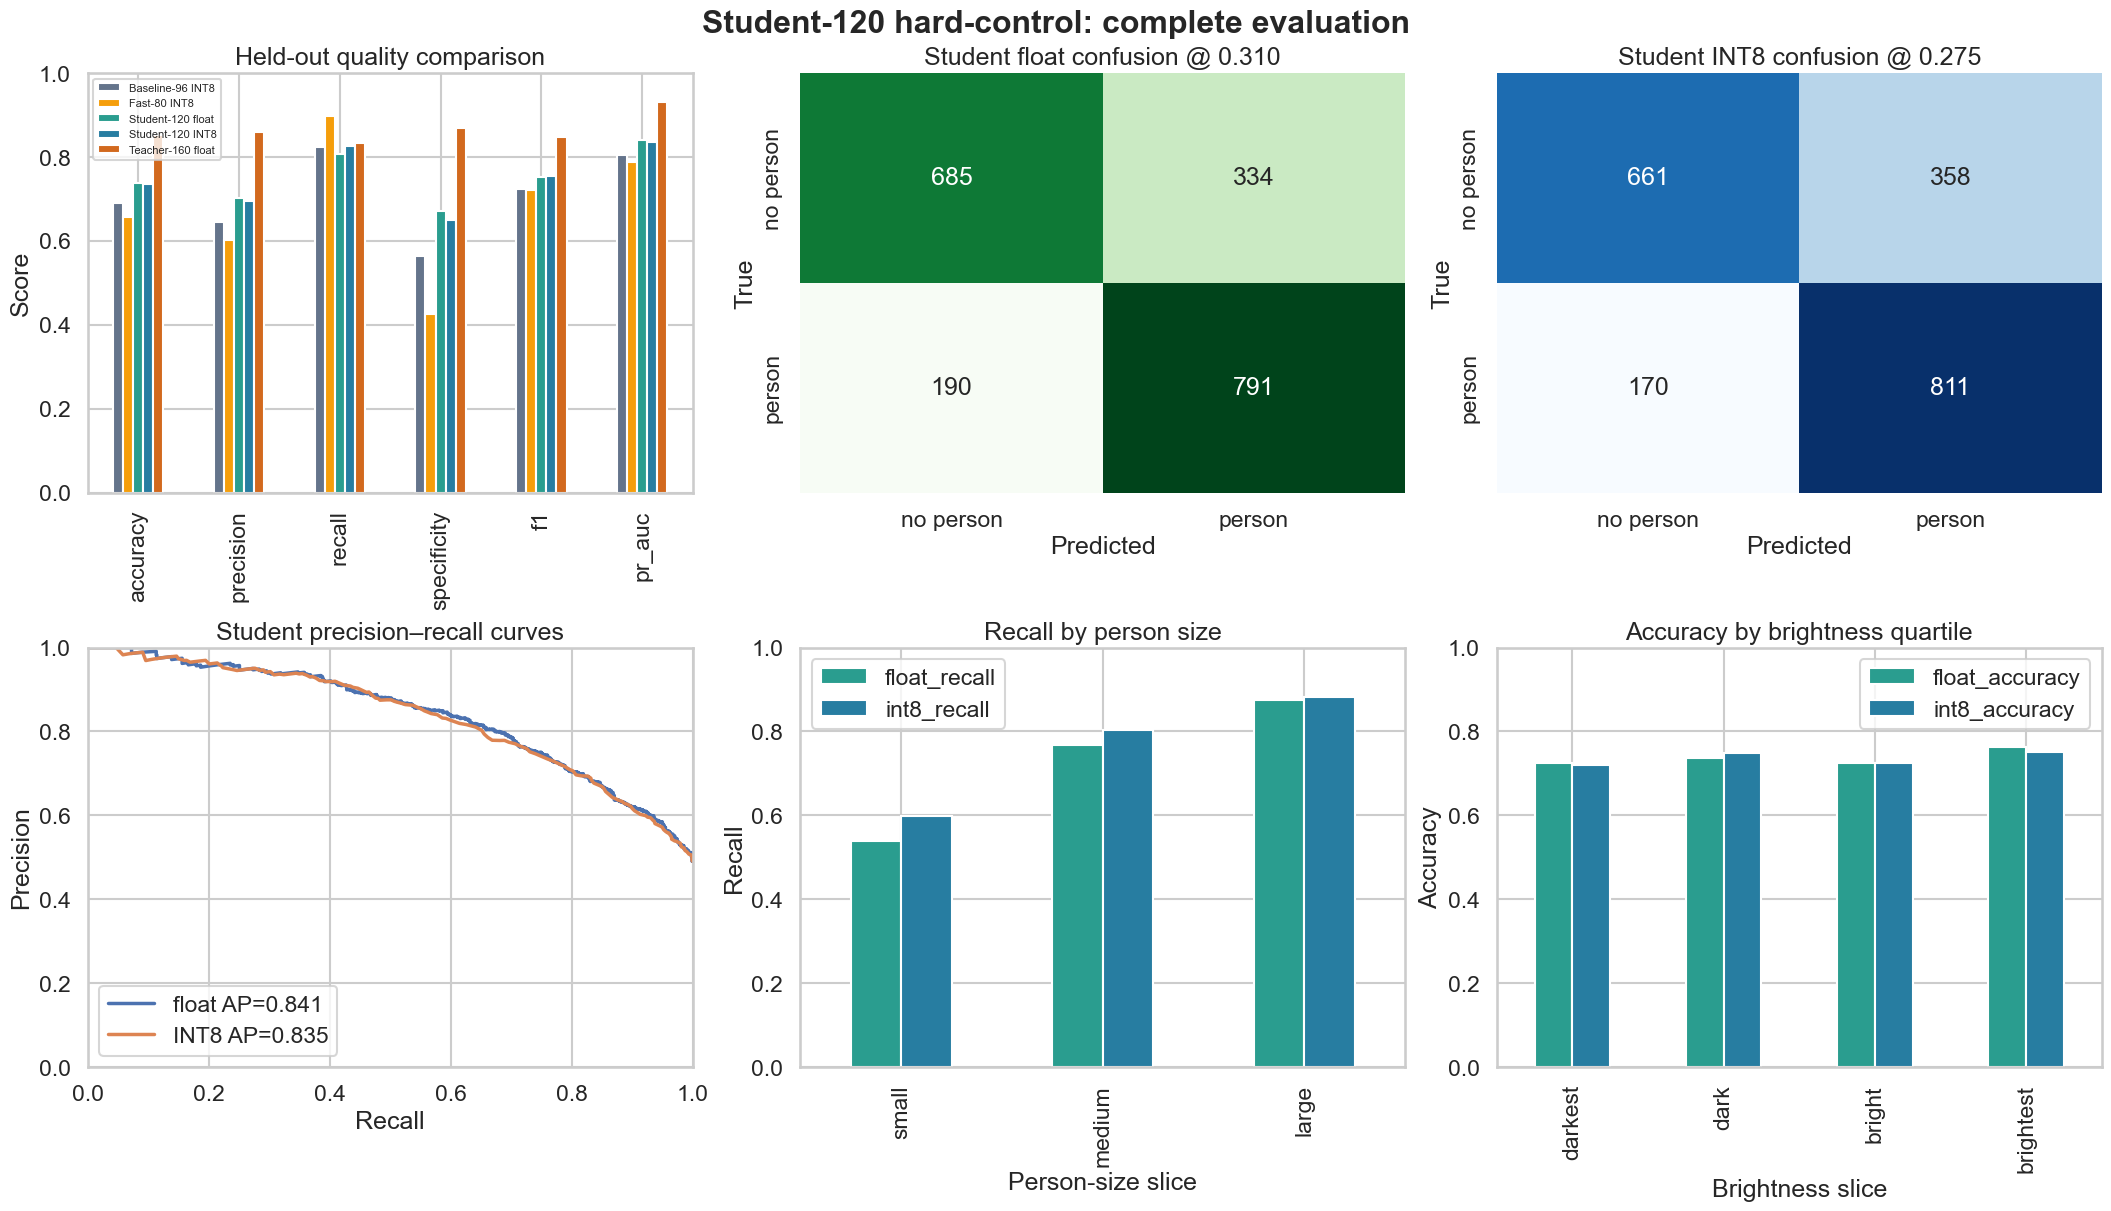

,accuracy,precision,recall,specificity,f1,pr_auc
model,,,,,,
Baseline-96 INT8,0.691,0.645,0.824,0.563,0.723,0.803
Fast-80 INT8,0.657,0.601,0.898,0.426,0.720,0.787
Student-120 float,0.738,0.703,0.806,0.672,0.751,0.841
Student-120 INT8,0.736,0.694,0.827,0.649,0.754,0.835
Teacher-160 float,0.852,0.859,0.834,0.868,0.846,0.930


,person_size,samples,float_recall,int8_recall
0,small,132,0.537879,0.598485
1,medium,220,0.768182,0.804545
2,large,629,0.875994,0.882353


,brightness_band,samples,float_accuracy,int8_accuracy
0,darkest,500,0.726,0.720
1,dark,500,0.736,0.748
2,bright,500,0.726,0.726
3,brightest,500,0.764,0.750


In [57]:
baseline96 = json.loads((ROOT / 'artifacts/reports/test_metrics.json').read_text())
fast80 = json.loads((ROOT / 'artifacts/fast_80/reports/test_metrics_int8.json').read_text())
teacher160 = teacher_summary['test_metrics']
comparison = pd.DataFrame({'Baseline-96 INT8': baseline96, 'Fast-80 INT8': fast80, 'Student-120 float': test_metrics, 'Student-120 INT8': int8_metrics, 'Teacher-160 float': teacher160}).T
comparison.index.name = 'model'
comparison.to_csv(REPORT_DIR / 'complete_quality_comparison.csv')
metrics = ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'pr_auc']
fig, axes = plt.subplots(2, 3, figsize=(21, 12), constrained_layout=True)
comparison[metrics].astype(float).T.plot(kind='bar', ax=axes[0, 0], ylim=(0, 1), color=['#64748b', '#f59e0b', '#2a9d8f', '#277da1', '#d2691e'])
axes[0, 0].set(title='Held-out quality comparison', ylabel='Score'); axes[0, 0].legend(fontsize=8)
sns.heatmap(np.asarray(test_metrics['confusion_matrix']), annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0, 1], xticklabels=['no person', 'person'], yticklabels=['no person', 'person'])
axes[0, 1].set(title=f"Student float confusion @ {test_metrics['threshold']:.3f}", xlabel='Predicted', ylabel='True')
sns.heatmap(np.asarray(int8_metrics['confusion_matrix']), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 2], xticklabels=['no person', 'person'], yticklabels=['no person', 'person'])
axes[0, 2].set(title=f"Student INT8 confusion @ {int8_metrics['threshold']:.3f}", xlabel='Predicted', ylabel='True')
precision_f, recall_f, _ = precision_recall_curve(y_test, p_test)
precision_i, recall_i, _ = precision_recall_curve(yi_test, pi_test)
axes[1, 0].plot(recall_f, precision_f, linewidth=2.5, label=f"float AP={test_metrics['pr_auc']:.3f}")
axes[1, 0].plot(recall_i, precision_i, linewidth=2.5, label=f"INT8 AP={int8_metrics['pr_auc']:.3f}")
axes[1, 0].set(title='Student precision–recall curves', xlabel='Recall', ylabel='Precision', xlim=(0, 1), ylim=(0, 1)); axes[1, 0].legend()
slice_frame = splits['test'][['label', 'max_person_area_fraction', 'brightness']].copy()
slice_frame['float_prediction'] = (p_test >= THRESHOLD).astype(np.int8); slice_frame['int8_prediction'] = (pi_test >= INT8_THRESHOLD).astype(np.int8)
positive = slice_frame[slice_frame.label == 1].copy(); positive['person_size'] = pd.cut(positive.max_person_area_fraction, [0.005, 0.025, 0.10, np.inf], labels=['small', 'medium', 'large'], include_lowest=True)
size_recall = positive.groupby('person_size', observed=True).agg(samples=('label', 'size'), float_recall=('float_prediction', 'mean'), int8_recall=('int8_prediction', 'mean')).reset_index()
size_recall.set_index('person_size')[['float_recall', 'int8_recall']].plot(kind='bar', ax=axes[1, 1], ylim=(0, 1), color=['#2a9d8f', '#277da1'])
axes[1, 1].set(title='Recall by person size', xlabel='Person-size slice', ylabel='Recall')
slice_frame['brightness_band'] = pd.qcut(slice_frame.brightness, 4, labels=['darkest', 'dark', 'bright', 'brightest'])
slice_frame['float_correct'] = slice_frame.float_prediction == slice_frame.label; slice_frame['int8_correct'] = slice_frame.int8_prediction == slice_frame.label
brightness_quality = slice_frame.groupby('brightness_band', observed=True).agg(samples=('label', 'size'), float_accuracy=('float_correct', 'mean'), int8_accuracy=('int8_correct', 'mean')).reset_index()
brightness_quality.set_index('brightness_band')[['float_accuracy', 'int8_accuracy']].plot(kind='bar', ax=axes[1, 2], ylim=(0, 1), color=['#2a9d8f', '#277da1'])
axes[1, 2].set(title='Accuracy by brightness quartile', xlabel='Brightness slice', ylabel='Accuracy')
fig.suptitle('Student-120 hard-control: complete evaluation', fontsize=23, weight='bold')
fig.savefig(FIGURE_DIR / 'complete_evaluation_dashboard.png', dpi=180, bbox_inches='tight')
plt.show()
size_recall.to_csv(REPORT_DIR / 'person_size_recall.csv', index=False); brightness_quality.to_csv(REPORT_DIR / 'brightness_quality.csv', index=False)
display(comparison[metrics].style.format('{:.3f}'))
display(size_recall); display(brightness_quality)

## Next decision

Notebook 02 must reuse this exact student and add only response KD, beginning with the MicroNets-derived anchor $T=4,\lambda=0.5$. A quality gain is not an efficiency gain because the inference graph is unchanged.

## 10 · Physical deployment and cross-version evidence

This section is deliberately artifact-driven: it does not retrain or reconvert a model. It reads
the immutable test metrics, static graph profiles, and physical device logs produced above and by
the ESP32 profilers. This prevents hardware timing from being confused with desktop estimates.

Measurement labels used below:

- **test**: frozen 2,000-image test set;
- **static estimate**: graph-derived parameters, MACs, or live activations;
- **physical**: batch-one TFLite Micro measurements on the named board;
- **pending**: no physical run exists for that exact model/board pair.

The ESP32-CAM deployment uses threshold `0.275`, a 2-of-3 temporal vote, and
`VWW_FLASH_LED_ENABLED=0`, which forces GPIO4 low without removing the feature.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'artifacts').exists():
            return candidate
    raise RuntimeError('Run this notebook from inside the visual-wake-word-esp32 repository')

ROOT = find_project_root()
DISTILLATION_DIR = ROOT / 'artifacts/distillation/reference_student_120'
REPORT_DIR = DISTILLATION_DIR / 'reports'
FIGURE_DIR = DISTILLATION_DIR / 'figures'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def read_json(path):
    return json.loads(Path(path).read_text())

quality = pd.read_csv(REPORT_DIR / 'complete_quality_comparison.csv')
prune_metrics = read_json(
    ROOT / 'artifacts/pruning/unstructured_magnitude/reports/selected_int8_test_metrics.json'
)['selected_int8']
prune_row = {
    'model': 'Pruned-S50 INT8',
    **{k: prune_metrics.get(k, np.nan) for k in
       ['samples', 'threshold', 'accuracy', 'precision', 'recall', 'f1',
        'roc_auc', 'pr_auc', 'specificity', 'predicted_positive_rate']},
}
quality = pd.concat([quality, pd.DataFrame([prune_row])], ignore_index=True)
quality_order = [
    'Teacher-160 float', 'Student-120 float', 'Student-120 INT8',
    'Baseline-96 INT8', 'Fast-80 INT8', 'Pruned-S50 INT8',
]
quality['model'] = pd.Categorical(quality['model'], quality_order, ordered=True)
quality = quality.sort_values('model').reset_index(drop=True)
quality_view = quality[
    ['model', 'threshold', 'accuracy', 'precision', 'recall', 'specificity',
     'f1', 'roc_auc', 'pr_auc', 'predicted_positive_rate']
].copy()
quality_view.to_csv(REPORT_DIR / 'all_model_quality_comparison.csv', index=False)

student_static = read_json(REPORT_DIR / 'student_static_profile_untrained.json')
baseline_static = read_json(ROOT / 'artifacts/reports/model_profile_summary.json')
fast_static = read_json(ROOT / 'artifacts/fast_80/reports/model_profile_summary.json')

resource_rows = [
    {'model': 'Teacher-160 float', 'input': '160x160x3', 'parameters': 830049,
     'macs': 76013312, 'peak_live_int8_est_bytes': 414752, 'tflite_bytes': np.nan,
     'evidence': 'static estimate; training-only teacher'},
    {'model': 'Student-120 INT8', 'input': '120x120x3',
     'parameters': student_static['parameters'], 'macs': student_static['estimated_macs_batch1'],
     'peak_live_int8_est_bytes': student_static['peak_live_activation_int8_bytes_batch1_hypothetical'],
     'tflite_bytes': (DISTILLATION_DIR / 'models/student_120_hard_control_int8.tflite').stat().st_size,
     'evidence': 'static estimate + exported flatbuffer'},
    {'model': 'Baseline-96 INT8', 'input': '96x96x3',
     'parameters': baseline_static['parameters'], 'macs': baseline_static['estimated_macs_batch1'],
     'peak_live_int8_est_bytes': baseline_static['peak_live_activation_int8_bytes_batch1_hypothetical'],
     'tflite_bytes': 167976, 'evidence': 'static estimate + exported flatbuffer'},
    {'model': 'Fast-80 INT8', 'input': '80x80x3',
     'parameters': fast_static['parameters'], 'macs': fast_static['estimated_macs_batch1'],
     'peak_live_int8_est_bytes': fast_static['peak_live_activation_int8_bytes_batch1_hypothetical'],
     'tflite_bytes': 167976, 'evidence': 'static estimate + exported flatbuffer'},
    {'model': 'Pruned-S50 INT8', 'input': '80x80x3',
     'parameters': fast_static['parameters'], 'macs': fast_static['estimated_macs_batch1'],
     'peak_live_int8_est_bytes': fast_static['peak_live_activation_int8_bytes_batch1_hypothetical'],
     'tflite_bytes': 167976,
     'evidence': 'unstructured zeros; dense ESP-NN graph cost unchanged'},
]
resources = pd.DataFrame(resource_rows)
resources.to_csv(REPORT_DIR / 'all_model_static_resource_comparison.csv', index=False)

def cam_row(directory, label):
    data = read_json(ROOT / f'artifacts/device_profiles/{directory}/device_profile_summary.json')
    return {
        'board': 'ESP32-CAM', 'model': label, 'placement': 'PSRAM',
        'invoke_mean_ms': data['mean_us'] / 1000,
        'invoke_min_ms': data['min_us'] / 1000,
        'invoke_max_ms': data['max_us'] / 1000,
        'arena_used_bytes': data['arena_used_bytes'],
        'model_bytes': data['model_bytes'], 'macs': data['estimated_macs'],
        'effective_mmac_s': data['estimated_macs'] / data['mean_us'],
        'pipeline_preprocess_ms': data.get('pipeline_preprocess_median_ms', np.nan),
        'pipeline_active_ms': data.get('pipeline_active_median_ms', np.nan),
        'pipeline_fps': data.get('pipeline_fps_median', np.nan),
        'status': 'physical',
    }

hardware_rows = [
    cam_row('baseline_96', 'Baseline-96 INT8'),
    cam_row('fast_80', 'Fast-80 INT8'),
    cam_row('prune_unstructured_iterative_s50', 'Pruned-S50 INT8'),
    cam_row('student_120_hard_control', 'Student-120 INT8'),
]
s3_fast = read_json(ROOT / 'artifacts/device_profiles/esp32_s3_capacity/device_profile_summary.json')
for placement in ['internal', 'psram']:
    lat = s3_fast['latency'][placement]
    model = s3_fast['models'][placement]
    hardware_rows.append({
        'board': 'ESP32-S3', 'model': 'Fast-80 INT8', 'placement': placement.upper(),
        'invoke_mean_ms': lat['mean_us'] / 1000, 'invoke_min_ms': lat['min_us'] / 1000,
        'invoke_max_ms': lat['max_us'] / 1000, 'arena_used_bytes': model['arena_used'],
        'model_bytes': model['model_bytes'], 'macs': fast_static['estimated_macs_batch1'],
        'effective_mmac_s': fast_static['estimated_macs_batch1'] / lat['mean_us'],
        'pipeline_preprocess_ms': np.nan, 'pipeline_active_ms': np.nan,
        'pipeline_fps': np.nan, 'status': 'physical',
    })

s3_student_path = ROOT / 'artifacts/device_profiles/student_120_hard_control/esp32_s3/device_profile_summary.json'
if s3_student_path.exists():
    s3_student = read_json(s3_student_path)
    for placement in ['internal', 'psram']:
        if placement not in s3_student.get('latency', {}):
            continue
        lat = s3_student['latency'][placement]
        model = s3_student['models'][placement]
        hardware_rows.append({
            'board': 'ESP32-S3', 'model': 'Student-120 INT8', 'placement': placement.upper(),
            'invoke_mean_ms': lat['mean_us'] / 1000, 'invoke_min_ms': lat['min_us'] / 1000,
            'invoke_max_ms': lat['max_us'] / 1000, 'arena_used_bytes': model['arena_used'],
            'model_bytes': model['model_bytes'], 'macs': student_static['estimated_macs_batch1'],
            'effective_mmac_s': student_static['estimated_macs_batch1'] / lat['mean_us'],
            'pipeline_preprocess_ms': np.nan, 'pipeline_active_ms': np.nan,
            'pipeline_fps': np.nan, 'status': 'physical',
        })
else:
    hardware_rows.append({
        'board': 'ESP32-S3', 'model': 'Student-120 INT8', 'placement': 'pending',
        **{column: np.nan for column in ['invoke_mean_ms', 'invoke_min_ms', 'invoke_max_ms',
            'arena_used_bytes', 'pipeline_preprocess_ms', 'pipeline_active_ms', 'pipeline_fps',
            'effective_mmac_s']},
        'model_bytes': int(resources.loc[resources.model == 'Student-120 INT8', 'tflite_bytes'].iloc[0]),
        'macs': student_static['estimated_macs_batch1'], 'status': 'pending physical board',
    })

hardware = pd.DataFrame(hardware_rows)
hardware.to_csv(REPORT_DIR / 'all_hardware_measurements.csv', index=False)

display(Markdown('### Frozen test-set model comparison'))
display(quality_view.style.format({
    'threshold': '{:.3f}', 'accuracy': '{:.2%}', 'precision': '{:.2%}', 'recall': '{:.2%}',
    'specificity': '{:.2%}', 'f1': '{:.2%}', 'roc_auc': '{:.2%}', 'pr_auc': '{:.2%}',
    'predicted_positive_rate': '{:.2%}',
}).background_gradient(subset=['accuracy', 'f1', 'pr_auc', 'specificity'], cmap='YlGn'))

display(Markdown('### Static deployment resources'))
display(resources.style.format({
    'parameters': '{:,.0f}', 'macs': '{:,.0f}', 'peak_live_int8_est_bytes': '{:,.0f}',
    'tflite_bytes': '{:,.0f}',
}).background_gradient(subset=['parameters', 'macs', 'peak_live_int8_est_bytes'], cmap='YlOrRd'))

display(Markdown('### Physical hardware measurements'))
display(hardware.style.format({
    'invoke_mean_ms': '{:,.2f}', 'invoke_min_ms': '{:,.2f}', 'invoke_max_ms': '{:,.2f}',
    'arena_used_bytes': '{:,.0f}', 'model_bytes': '{:,.0f}', 'macs': '{:,.0f}',
    'effective_mmac_s': '{:.2f}', 'pipeline_preprocess_ms': '{:.2f}',
    'pipeline_active_ms': '{:.2f}', 'pipeline_fps': '{:.2f}',
}).background_gradient(subset=['invoke_mean_ms', 'arena_used_bytes'], cmap='YlOrRd'))

### Frozen test-set model comparison

,model,threshold,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,predicted_positive_rate
0,Teacher-160 float,0.365,85.15%,85.92%,83.38%,86.85%,84.64%,92.15%,93.05%,47.60%
1,Student-120 float,0.310,73.80%,70.31%,80.63%,67.22%,75.12%,83.18%,84.06%,56.25%
2,Student-120 INT8,0.275,73.60%,69.38%,82.67%,64.87%,75.44%,82.72%,83.53%,58.45%
3,Baseline-96 INT8,0.340,69.10%,64.49%,82.36%,56.33%,72.34%,80.09%,80.34%,62.65%
4,Fast-80 INT8,0.270,65.75%,60.10%,89.81%,42.59%,72.01%,78.82%,78.73%,73.30%
5,Pruned-S50 INT8,0.470,68.35%,63.45%,83.69%,53.58%,72.18%,78.59%,78.10%,64.70%


### Static deployment resources

,model,input,parameters,macs,peak_live_int8_est_bytes,tflite_bytes,evidence
0,Teacher-160 float,160x160x3,"830,049","76,013,312","414,752",nan,static estimate; training-only teacher
1,Student-120 INT8,120x120x3,"218,801","10,487,648","117,136","304,296",static estimate + exported flatbuffer
2,Baseline-96 INT8,96x96x3,"111,793","5,616,256","73,728","167,976",static estimate + exported flatbuffer
3,Fast-80 INT8,80x80x3,"111,793","3,993,536","51,200","167,976",static estimate + exported flatbuffer
4,Pruned-S50 INT8,80x80x3,"111,793","3,993,536","51,200","167,976",unstructured zeros; dense ESP-NN graph cost unchanged


### Physical hardware measurements

,board,model,placement,invoke_mean_ms,invoke_min_ms,invoke_max_ms,arena_used_bytes,model_bytes,macs,effective_mmac_s,pipeline_preprocess_ms,pipeline_active_ms,pipeline_fps,status
0,ESP32-CAM,Baseline-96 INT8,PSRAM,640.53,638.39,644.10,"91,596","167,976","5,616,256",8.77,nan,nan,nan,physical
1,ESP32-CAM,Fast-80 INT8,PSRAM,455.55,453.36,459.70,"69,068","167,976","3,993,536",8.77,nan,nan,nan,physical
2,ESP32-CAM,Pruned-S50 INT8,PSRAM,416.80,415.53,418.81,"69,068","167,976","3,993,536",9.58,59.80,499.00,1.68,physical
3,ESP32-CAM,Student-120 INT8,PSRAM,"1,117.12","1,114.85","1,121.74","142,444","304,296","10,487,648",9.39,95.50,1256.10,0.74,physical
4,ESP32-S3,Fast-80 INT8,INTERNAL,67.10,67.09,67.13,"83,420","167,976","3,993,536",59.51,nan,nan,nan,physical
5,ESP32-S3,Fast-80 INT8,PSRAM,73.48,73.45,73.51,"83,420","167,976","3,993,536",54.35,nan,nan,nan,physical
6,ESP32-S3,Student-120 INT8,INTERNAL,150.91,150.89,150.93,"159,212","304,296","10,487,648",69.50,nan,nan,nan,physical
7,ESP32-S3,Student-120 INT8,PSRAM,176.01,175.98,176.03,"159,212","304,296","10,487,648",59.59,nan,nan,nan,physical


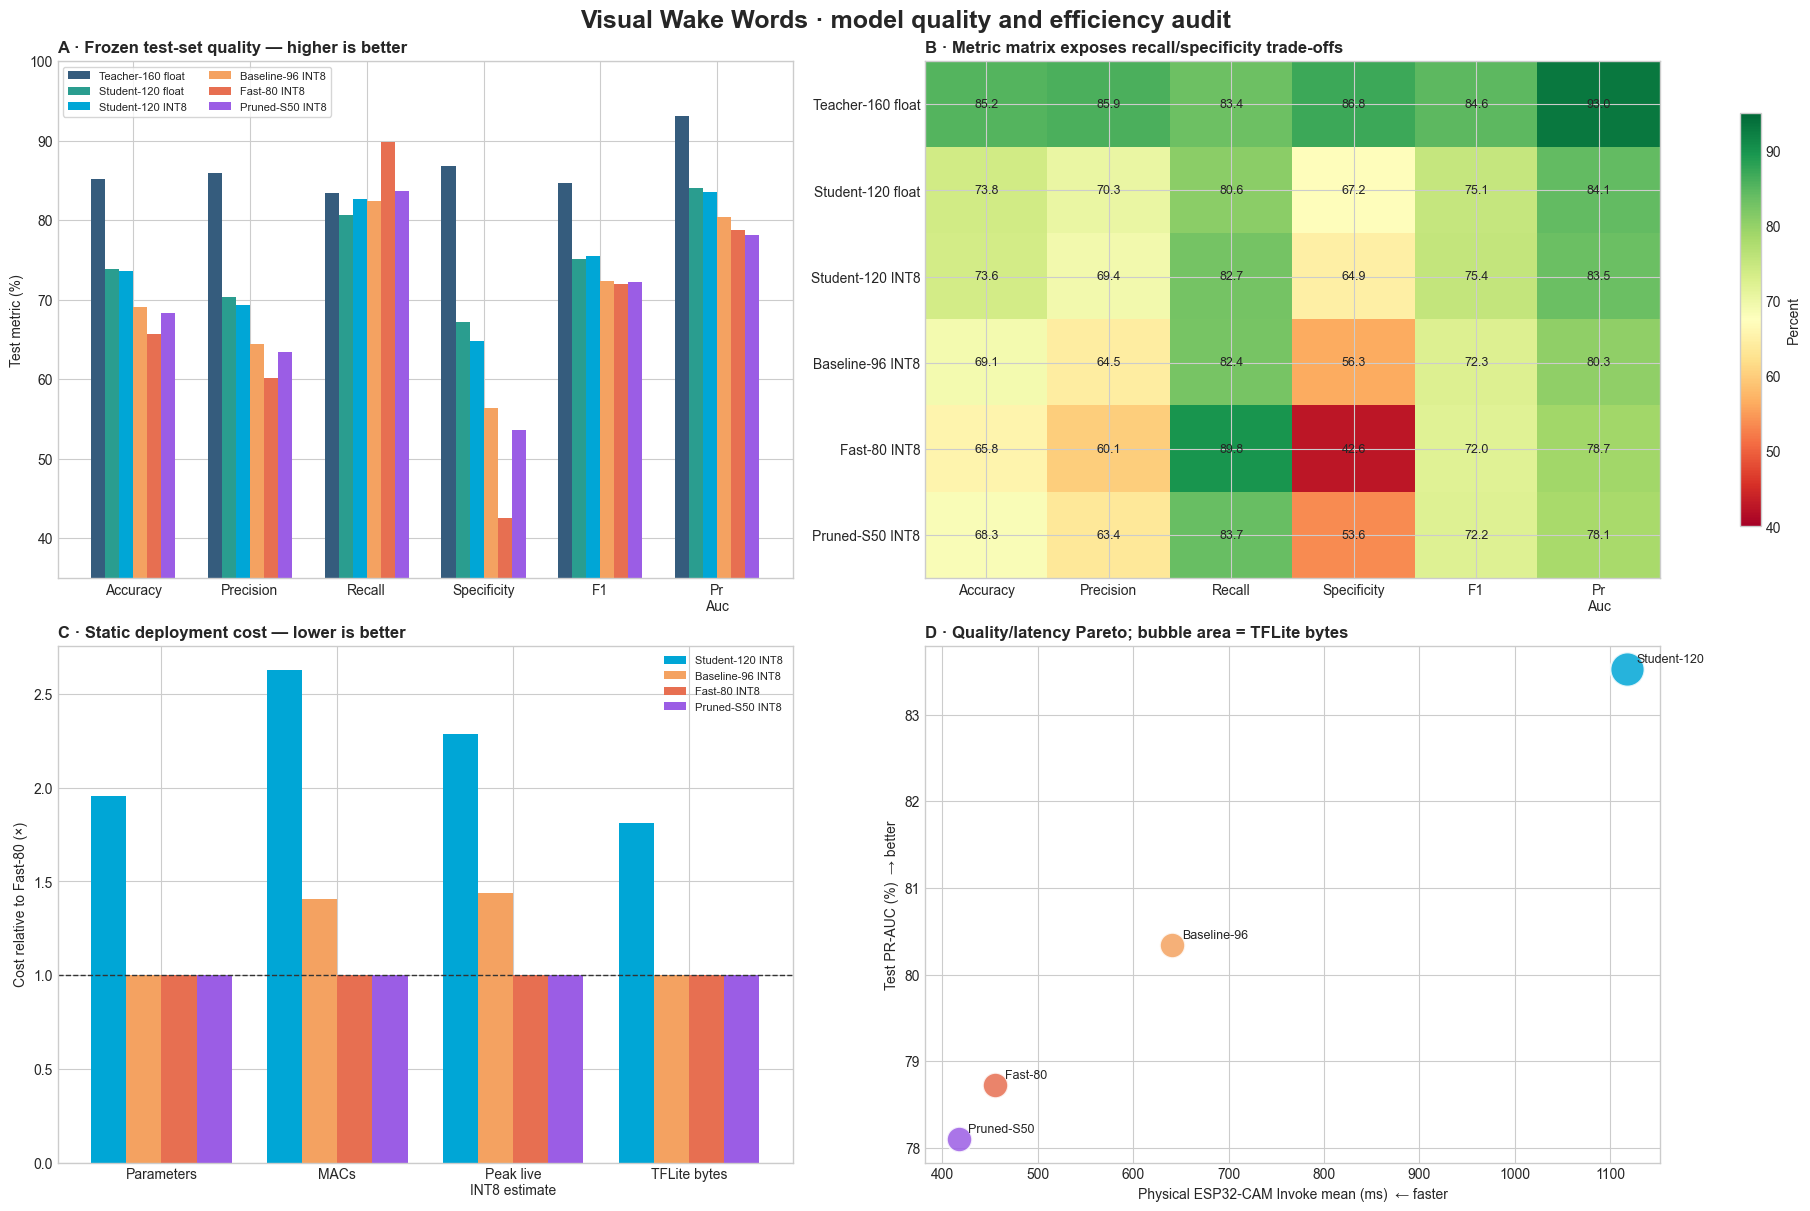

Saved: artifacts/distillation/reference_student_120/figures/all_model_quality_efficiency_comparison.png


In [2]:
# Model quality, resource cost, and quality/latency Pareto view
plt.style.use('seaborn-v0_8-whitegrid')
colors = {
    'Teacher-160 float': '#355C7D', 'Student-120 float': '#2A9D8F',
    'Student-120 INT8': '#00A6D6', 'Baseline-96 INT8': '#F4A261',
    'Fast-80 INT8': '#E76F51', 'Pruned-S50 INT8': '#9B5DE5',
}
fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

metrics = ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'pr_auc']
x = np.arange(len(metrics))
width = 0.12
for index, row in quality_view.iterrows():
    name = str(row['model'])
    axes[0, 0].bar(x + (index - 2.5) * width, row[metrics].astype(float) * 100,
                   width, label=name, color=colors.get(name, '#777777'))
axes[0, 0].set_xticks(x, [m.replace('_', '\n').title() for m in metrics])
axes[0, 0].set_ylim(35, 100)
axes[0, 0].set_ylabel('Test metric (%)')
axes[0, 0].set_title('A · Frozen test-set quality — higher is better', loc='left', fontweight='bold')
axes[0, 0].legend(ncol=2, fontsize=8, frameon=True)

heat = quality_view.set_index('model')[metrics].astype(float) * 100
image = axes[0, 1].imshow(heat, cmap='RdYlGn', vmin=40, vmax=95, aspect='auto')
axes[0, 1].set_xticks(range(len(metrics)), [m.replace('_', '\n').title() for m in metrics])
axes[0, 1].set_yticks(range(len(heat)), heat.index.astype(str))
for i in range(len(heat)):
    for j in range(len(metrics)):
        axes[0, 1].text(j, i, f'{heat.iloc[i, j]:.1f}', ha='center', va='center', fontsize=9)
axes[0, 1].set_title('B · Metric matrix exposes recall/specificity trade-offs', loc='left', fontweight='bold')
fig.colorbar(image, ax=axes[0, 1], shrink=.8, label='Percent')

deploy_resources = resources[resources.model != 'Teacher-160 float'].copy()
resource_metrics = ['parameters', 'macs', 'peak_live_int8_est_bytes', 'tflite_bytes']
normalized = deploy_resources.set_index('model')[resource_metrics].astype(float)
normalized = normalized.div(normalized.loc['Fast-80 INT8'])
rx = np.arange(len(resource_metrics))
rw = 0.2
for index, (name, row) in enumerate(normalized.iterrows()):
    axes[1, 0].bar(rx + (index - 1.5) * rw, row, rw, label=name,
                   color=colors.get(name, '#777777'))
axes[1, 0].axhline(1, color='#333333', lw=1, ls='--')
axes[1, 0].set_xticks(rx, ['Parameters', 'MACs', 'Peak live\nINT8 estimate', 'TFLite bytes'])
axes[1, 0].set_ylabel('Cost relative to Fast-80 (×)')
axes[1, 0].set_title('C · Static deployment cost — lower is better', loc='left', fontweight='bold')
axes[1, 0].legend(fontsize=8)

cam_physical = hardware[(hardware.board == 'ESP32-CAM') & hardware.invoke_mean_ms.notna()].copy()
pareto = cam_physical.merge(quality_view[['model', 'pr_auc', 'f1']], on='model', how='left')
for _, row in pareto.iterrows():
    size = row['model_bytes'] / 500
    axes[1, 1].scatter(row['invoke_mean_ms'], row['pr_auc'] * 100, s=size,
                       color=colors.get(row['model'], '#777777'), alpha=.85,
                       edgecolor='white', linewidth=1.5)
    axes[1, 1].annotate(row['model'].replace(' INT8', ''),
                        (row['invoke_mean_ms'], row['pr_auc'] * 100),
                        xytext=(7, 5), textcoords='offset points', fontsize=9)
axes[1, 1].set_xlabel('Physical ESP32-CAM Invoke mean (ms)  ← faster')
axes[1, 1].set_ylabel('Test PR-AUC (%)  → better')
axes[1, 1].set_title('D · Quality/latency Pareto; bubble area = TFLite bytes', loc='left', fontweight='bold')

fig.suptitle('Visual Wake Words · model quality and efficiency audit', fontsize=18, fontweight='bold')
model_figure = FIGURE_DIR / 'all_model_quality_efficiency_comparison.png'
fig.savefig(model_figure, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved: {model_figure.relative_to(ROOT)}')

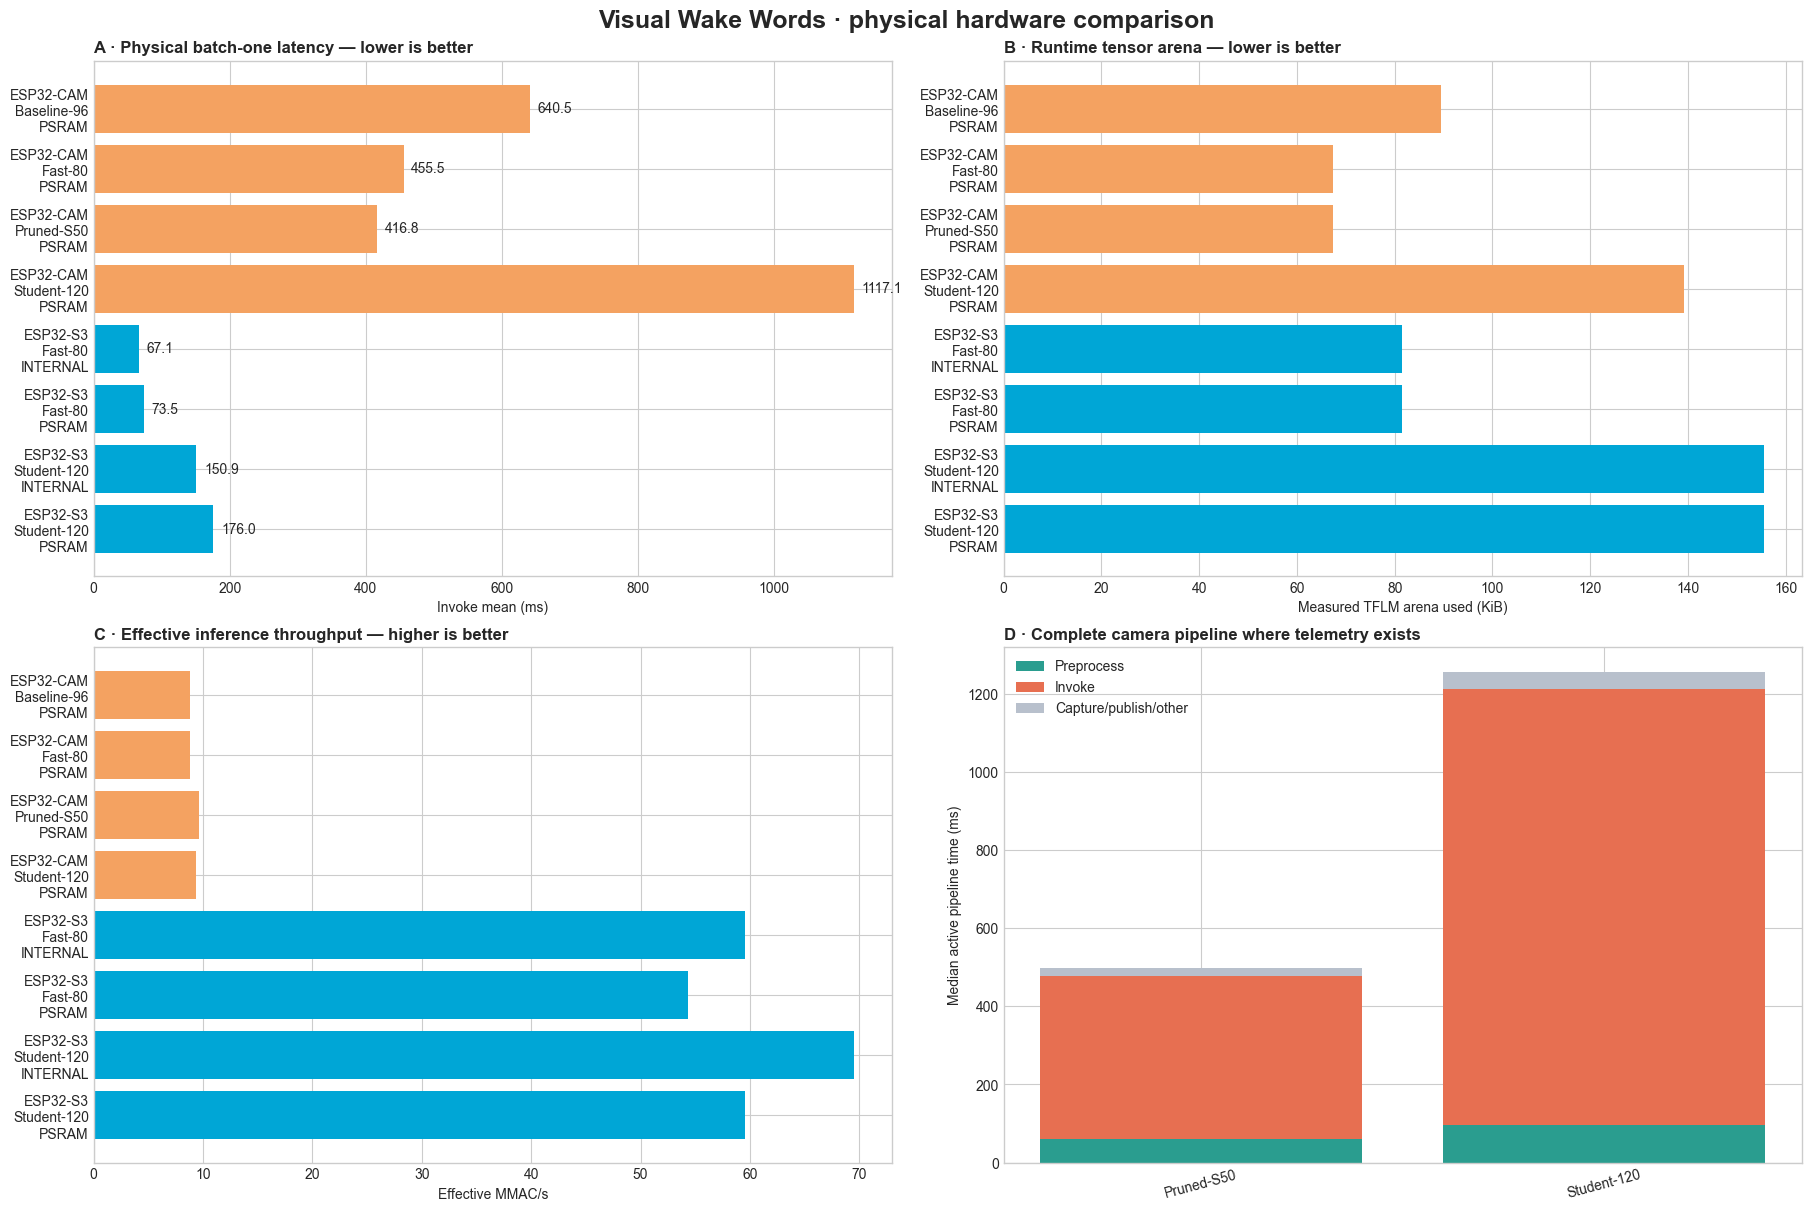

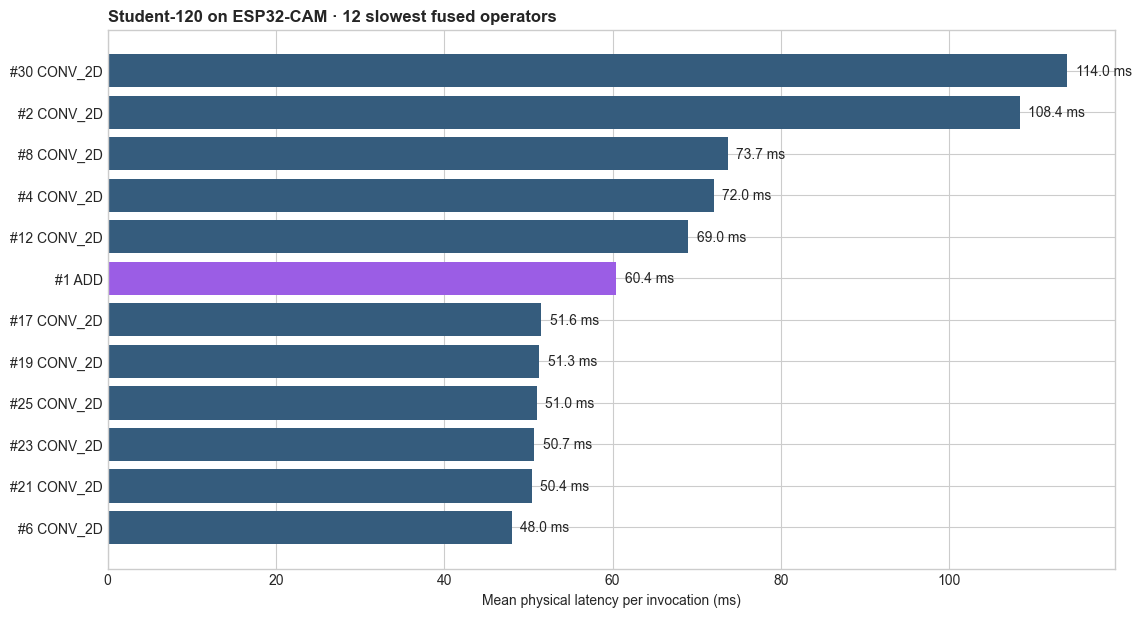

### Engineering interpretation

- Student-120 is **2.45× slower** than Fast-80 on ESP32-CAM
  (1117.1 vs 455.5 ms Invoke).
- Its measured tensor arena is **2.06× larger**
  (142,444 vs 69,068 bytes).
- The full Student-120 camera loop reaches **0.74 FPS**; inference dominates the active pipeline.
- Student-120 improves PR-AUC and specificity, but it is not an ESP32-CAM Pareto winner unless quality is prioritized over response time.
- On ESP32-S3, Student-120 takes **150.9 ms** from internal SRAM and
  **176.0 ms** from PSRAM. Internal placement is
  **14.26% faster**.
- The ESP32-S3 internal-SRAM run is **7.40× faster**
  than the ESP32-CAM run for the exact same FlatBuffer.


Saved: artifacts/distillation/reference_student_120/figures/all_hardware_metric_comparison.png
Saved: artifacts/distillation/reference_student_120/figures/student_120_esp32_cam_operator_bottlenecks.png


In [3]:
# Physical board dashboard and Student-120 ESP32-CAM operator bottlenecks
physical = hardware[hardware.status == 'physical'].copy()
physical['label'] = physical['board'] + '\n' + physical['model'].str.replace(' INT8', '') + '\n' + physical['placement']
palette = ['#F4A261' if board == 'ESP32-CAM' else '#00A6D6' for board in physical.board]

fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
axes[0, 0].barh(physical.label, physical.invoke_mean_ms, color=palette)
axes[0, 0].invert_yaxis()
axes[0, 0].set_xlabel('Invoke mean (ms)')
axes[0, 0].set_title('A · Physical batch-one latency — lower is better', loc='left', fontweight='bold')
for patch, value in zip(axes[0, 0].patches, physical.invoke_mean_ms):
    axes[0, 0].text(value + max(physical.invoke_mean_ms) * .01,
                    patch.get_y() + patch.get_height()/2, f'{value:.1f}', va='center')

axes[0, 1].barh(physical.label, physical.arena_used_bytes / 1024, color=palette)
axes[0, 1].invert_yaxis()
axes[0, 1].set_xlabel('Measured TFLM arena used (KiB)')
axes[0, 1].set_title('B · Runtime tensor arena — lower is better', loc='left', fontweight='bold')

axes[1, 0].barh(physical.label, physical.effective_mmac_s, color=palette)
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlabel('Effective MMAC/s')
axes[1, 0].set_title('C · Effective inference throughput — higher is better', loc='left', fontweight='bold')

cam_pipeline = hardware[(hardware.board == 'ESP32-CAM') & hardware.pipeline_active_ms.notna()].copy()
if len(cam_pipeline):
    labels = cam_pipeline.model.str.replace(' INT8', '')
    preprocess = cam_pipeline.pipeline_preprocess_ms.fillna(0).to_numpy()
    inference = cam_pipeline.invoke_mean_ms.to_numpy()
    other = np.maximum(cam_pipeline.pipeline_active_ms.to_numpy() - preprocess - inference, 0)
    axes[1, 1].bar(labels, preprocess, label='Preprocess', color='#2A9D8F')
    axes[1, 1].bar(labels, inference, bottom=preprocess, label='Invoke', color='#E76F51')
    axes[1, 1].bar(labels, other, bottom=preprocess + inference, label='Capture/publish/other', color='#B8C0CC')
    axes[1, 1].tick_params(axis='x', rotation=15)
    axes[1, 1].legend()
axes[1, 1].set_ylabel('Median active pipeline time (ms)')
axes[1, 1].set_title('D · Complete camera pipeline where telemetry exists', loc='left', fontweight='bold')

fig.suptitle('Visual Wake Words · physical hardware comparison', fontsize=18, fontweight='bold')
hardware_figure = FIGURE_DIR / 'all_hardware_metric_comparison.png'
fig.savefig(hardware_figure, dpi=180, bbox_inches='tight')
plt.show()

operator_path = ROOT / 'artifacts/device_profiles/student_120_hard_control/operator_profile.csv'
operators = pd.read_csv(operator_path)
top_ops = operators.nlargest(12, 'mean_us').sort_values('mean_us')
fig, ax = plt.subplots(figsize=(13, 7))
op_colors = top_ops['operator'].map({
    'CONV_2D': '#355C7D', 'DEPTHWISE_CONV_2D': '#2A9D8F',
    'PAD': '#F4A261', 'ADD': '#9B5DE5', 'MUL': '#E76F51',
}).fillna('#7A869A')
labels = [f"#{int(i)} {op}" for i, op in zip(top_ops['index'], top_ops.operator)]
ax.barh(labels, top_ops.mean_us / 1000, color=op_colors)
ax.set_xlabel('Mean physical latency per invocation (ms)')
ax.set_title('Student-120 on ESP32-CAM · 12 slowest fused operators', loc='left', fontweight='bold')
for patch, value in zip(ax.patches, top_ops.mean_us / 1000):
    ax.text(value + 1, patch.get_y() + patch.get_height()/2, f'{value:.1f} ms', va='center')
operator_figure = FIGURE_DIR / 'student_120_esp32_cam_operator_bottlenecks.png'
fig.savefig(operator_figure, dpi=180, bbox_inches='tight')
plt.show()

student_cam = hardware[(hardware.board == 'ESP32-CAM') & (hardware.model == 'Student-120 INT8')].iloc[0]
fast_cam = hardware[(hardware.board == 'ESP32-CAM') & (hardware.model == 'Fast-80 INT8')].iloc[0]
s3_student = hardware[(hardware.board == 'ESP32-S3') & (hardware.model == 'Student-120 INT8')]
if len(s3_student) and (s3_student.status == 'physical').all():
    s3_internal = s3_student[s3_student.placement == 'INTERNAL'].iloc[0]
    s3_psram = s3_student[s3_student.placement == 'PSRAM'].iloc[0]
    s3_finding = f"""- On ESP32-S3, Student-120 takes **{s3_internal.invoke_mean_ms:.1f} ms** from internal SRAM and
  **{s3_psram.invoke_mean_ms:.1f} ms** from PSRAM. Internal placement is
  **{(1 - s3_internal.invoke_mean_ms / s3_psram.invoke_mean_ms) * 100:.2f}% faster**.
- The ESP32-S3 internal-SRAM run is **{student_cam.invoke_mean_ms / s3_internal.invoke_mean_ms:.2f}× faster**
  than the ESP32-CAM run for the exact same FlatBuffer."""
else:
    s3_finding = '- ESP32-S3 Student-120 remains pending; no latency is inferred from MACs.'
display(Markdown(f"""### Engineering interpretation

- Student-120 is **{student_cam.invoke_mean_ms / fast_cam.invoke_mean_ms:.2f}× slower** than Fast-80 on ESP32-CAM
  ({student_cam.invoke_mean_ms:.1f} vs {fast_cam.invoke_mean_ms:.1f} ms Invoke).
- Its measured tensor arena is **{student_cam.arena_used_bytes / fast_cam.arena_used_bytes:.2f}× larger**
  ({student_cam.arena_used_bytes:,.0f} vs {fast_cam.arena_used_bytes:,.0f} bytes).
- The full Student-120 camera loop reaches **{student_cam.pipeline_fps:.2f} FPS**; inference dominates the active pipeline.
- Student-120 improves PR-AUC and specificity, but it is not an ESP32-CAM Pareto winner unless quality is prioritized over response time.
{s3_finding}
"""))
print(f'Saved: {hardware_figure.relative_to(ROOT)}')
print(f'Saved: {operator_figure.relative_to(ROOT)}')

## 11 · Deployment gate after physical profiling

The exact 304,296-byte Student-120 INT8 FlatBuffer is now physically verified on both targets.
ESP32-CAM remains a quality-oriented research deployment at 1,117 ms model Invoke and 0.74 FPS
for the measured camera loop. ESP32-S3 is the practical Student-120 target: internal-SRAM arena
placement reaches 150.906 ms model latency (6.63 model-only FPS), versus 176.005 ms in PSRAM.

The same model is therefore 7.40× faster on ESP32-S3 than ESP32-CAM. Response distillation remains
the next controlled scientific experiment because it may improve quality without changing this
fixed graph cost; architecture, resolution, or operator changes are required to reduce latency.
